
# Paso 01 — Empleo como masa de destino (Tarea 2)

**Resuelta con datos ya disponibles, sin necesitar la API de StatBank.**

## Por qué

El plan original (instrucción del usuario) era: la capa `bedrifter_250m` es "conteo de
establecimientos, NO número de trabajadores" — un proxy débil, y la masa de empleo buena
había que traerla por API del StatBank de SSB (`sysselsatte etter arbeidssted`, al nivel
geográfico más fino disponible: grunnkrets o delområde).

Al inspeccionar el archivo (paso 00), encontramos que **`bedrifter_250m` ya trae una
columna `emp_tot`** con empleo real (no solo conteo de empresas). Y al explorar la API de
StatBank (`https://data.ssb.no/api/v0/no/table/al/al06/regsys/SBMENU4262`, tabla **12850**:
"Sysselsatte, etter bosted, arbeidssted, næring..."), su variable `Region` **solo baja a
nivel fylke/kommune** (Vestland, Bergen, etc.), no a grunnkrets — SSB no publica empleo por
lugar de trabajo a grano fino vía tablas StatBank por reglas de privacidad; en cambio lo
publica como grilla, que es exactamente lo que ya tenemos.

**Conclusión: `emp_tot` de la grilla de 250 m es la fuente correcta — de hecho más fina
que grunnkrets — y no hace falta la API.**


In [1]:

import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / "src"))
import masas

BASE_DIR = Path.cwd().parent
CONFIG_PATH = BASE_DIR / "config" / "instance.yaml"
OUTPUT_DIR = BASE_DIR / "output"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

cfg = masas.cargar_config(CONFIG_PATH)
plt.rcParams["figure.dpi"] = 110


## `emp_tot` vs. `est_tot` en la zona de estudio (Bergen + Askøy)

Se usa el recorte ya cacheado en el paso 00 (no se vuelve a leer el archivo de 48 MB
completo). Si `emp_tot` fuera solo ruido/conteo de empresas, no debería tener relación
sistemática con `est_tot`; si es empleo real, se espera una correlación positiva pero
imperfecta (una empresa grande con pocos establecimientos concentra mucho empleo).


In [2]:

bedrifter = gpd.read_parquet(PROCESSED_DIR / "bedrifter_bergen_askoy.parquet")
col_emp = cfg["datos_ssb"]["empleo_columna"]
col_est = cfg["datos_ssb"]["establecimientos_columna"]

print(f"Celdas en la zona de estudio: {len(bedrifter):,}")
print(f"Correlación {col_est} vs {col_emp}: {bedrifter[[col_est, col_emp]].corr().iloc[0,1]:.3f}")
print()
print(bedrifter[[col_est, col_emp]].describe())


Celdas en la zona de estudio: 2,127
Correlación est_tot vs emp_tot: 0.581

           est_tot       emp_tot
count  2127.000000   2127.000000
mean     12.385049     75.644100
std      28.015935    346.860311
min       1.000000      0.000000
25%       2.000000      0.000000
50%       5.000000      3.000000
75%      12.000000     31.000000
max     469.000000  10628.000000


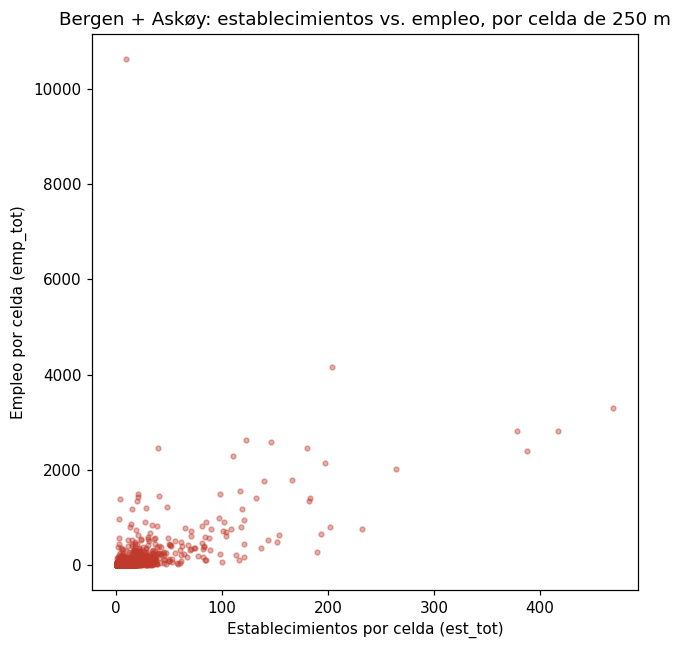

In [3]:

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(bedrifter[col_est], bedrifter[col_emp], s=10, alpha=0.4, color="#c0392b")
ax.set_xlabel("Establecimientos por celda (est_tot)")
ax.set_ylabel("Empleo por celda (emp_tot)")
ax.set_title("Bergen + Askøy: establecimientos vs. empleo, por celda de 250 m")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "establecimientos_vs_empleo.png", dpi=180, bbox_inches="tight")
plt.show()


## Comparación por nodo (de la tabla de masas del paso 00)

`empleo_media_celda` bien por encima de `establecimientos_total` promedio por celda
confirma que no es un simple reescalado de `est_tot` — Bryggen concentra desproporcionadamente
más empleo que establecimientos (oficinas grandes), consistente con ser el hub central.


In [4]:

resumen = pd.read_csv(OUTPUT_DIR / "masas_por_nodo.csv", index_col="id")
resumen[["establecimientos_total", "empleo_total", "empleo_media_celda"]].assign(
    empleados_por_establecimiento=lambda d: (d["empleo_total"] / d["establecimientos_total"]).round(1)
)


,establecimientos_total,empleo_total,empleo_media_celda,empleados_por_establecimiento
id,,,,
kleppesto,1884,7550,20.46,4.0
laksevag,1447,7760,93.49,5.4
bryggen,7101,52213,614.27,7.4
sandviken,879,4106,63.17,4.7



## Resumen

- Tarea 2 resuelta con `emp_tot` de la grilla SSB de 250 m — empleo real por lugar de
  trabajo, más fino que cualquier tabla StatBank disponible (que solo baja a fylke/kommune).
- `est_tot` (establecimientos) se guarda como referencia comparativa (`output/establecimientos_vs_empleo.png`),
  no se usa como masa principal.
- Pendiente declarado (no resuelto aquí): el empleo no captura población **estudiantil**
  universitaria (NHH, UiB, HVL) — placeholder `masas.factor_universitario` en el config,
  todo en 1.0 por ahora.
- **Siguiente paso:** `02_patron_od.ipynb` — Tarea 3, patrón origen-destino por franja horaria.
